# 🛠️ GoldMind - Stationary Feature Engineering
This notebook generates 45+ scale-invariant, stationary technical indicators for XAU/USD.

### ⚠️ Critical Note on Stationarity in Machine Learning
Tree models (Random Forest, XGBoost) split on raw numeric thresholds. 
If raw price levels (e.g. `ma_200`, `close_lag_1h`, `bb_upper`) are used as features:
- In Gold's bull market (e.g. \$2,000 in train $\rightarrow$ \$5,000 in test), **every test sample falls outside the training range**.
- The tree maps all test data to a single extreme leaf node, causing catastrophic bias.
- **Solution:** All indicators MUST be normalized relative to current price or bounded (e.g. `Close/MA - 1`, `%B`, normalized ATR, return lags, cyclical time encodings).


In [1]:
import os
import sys
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

CSV_PATH = "data/XAU_1m_data.csv"
OUT_DIR = "model_output"
os.makedirs(OUT_DIR, exist_ok=True)
print("Features notebook initialized.")


Features notebook initialized.


In [2]:
# ===========================================================================
# Stationary Feature Engineering & Target Functions (Standalone)
# ===========================================================================

def _rsi(close: pd.Series, period: int = 14) -> pd.Series:
    """Standard Relative Strength Index (RSI) using Wilder's EMA smoothing."""
    delta = close.diff()
    gain = delta.clip(lower=0).ewm(alpha=1.0 / period, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1.0 / period, adjust=False).mean()
    rs = np.where(loss == 0, np.nan, gain / loss)
    rsi = np.where(
        loss == 0,
        np.where(gain == 0, 50.0, 100.0),
        np.where(gain == 0, 0.0, 100.0 - (100.0 / (1.0 + rs))),
    )
    return pd.Series(rsi, index=close.index)


def _atr(df: pd.DataFrame, period: int = 14) -> pd.Series:
    """Average True Range (ATR) in dollar units."""
    hl = df["High"] - df["Low"]
    hc = (df["High"] - df["Close"].shift()).abs()
    lc = (df["Low"] - df["Close"].shift()).abs()
    tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
    return tr.rolling(period).mean()


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build stationary and scale-invariant technical indicators from hourly OHLCV data.
    Raw dollar price levels are excluded to prevent decision trees from failing out-of-distribution.
    """
    f = pd.DataFrame(index=df.index)
    close, high, low, open_px, vol = df["Close"], df["High"], df["Low"], df["Open"], df["Volume"]

    # 1. Multi-horizon momentum returns
    for w in [1, 2, 3, 5, 8, 13, 21, 34]:
        f[f"ret_{w}"] = close.pct_change(w)
    f["ret_240"] = close.pct_change(240)

    # 2. Autoregressive past 1-bar returns (shifted lags)
    ret_1h = close.pct_change(1)
    for lag in [1, 2, 3, 5, 10]:
        f[f"ret_lag_{lag}h"] = ret_1h.shift(lag)

    # 3. Relative distance to Moving Averages (Close / MA - 1)
    for w in [5, 10, 20, 50, 100, 200]:
        ma = close.rolling(w).mean()
        f[f"px_over_ma_{w}"] = (close / ma) - 1.0

    # 4. Volatility (rolling std of percentage returns)
    for w in [5, 10, 20, 50]:
        f[f"vol_{w}"] = ret_1h.rolling(w).std()

    # 5. Normalized ATR & Candle Range
    atr_14 = _atr(df, 14)
    atr_50 = _atr(df, 50)
    f["atr_pct_14"] = atr_14 / close
    f["atr_pct_50"] = atr_50 / close
    f["hl_range"] = (high - low) / close
    f["oc_range"] = (close - open_px) / open_px

    # 6. Normalized Bollinger Bands (%B and BandWidth)
    bb_ma = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    bb_width_abs = 4.0 * bb_std
    f["bb_pct_b"] = (close - (bb_ma - 2.0 * bb_std)) / bb_width_abs.replace(0, np.nan)
    f["bb_width"] = bb_width_abs / bb_ma

    # 7. Wilder's RSI (bounded 0-100)
    for p in [7, 14, 21]:
        f[f"rsi_{p}"] = _rsi(close, p)

    # 8. Normalized MACD
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd_norm = (ema12 - ema26) / close
    macd_signal_norm = macd_norm.ewm(span=9, adjust=False).mean()
    f["macd_norm"] = macd_norm
    f["macd_signal_norm"] = macd_signal_norm
    f["macd_hist_norm"] = macd_norm - macd_signal_norm

    # 9. Volume Indicators
    f["vol_change"] = vol.pct_change()
    vol_mean_20 = vol.rolling(20).mean()
    vol_std_20 = vol.rolling(20).std()
    f["vol_zscore_20"] = (vol - vol_mean_20) / vol_std_20.replace(0, np.nan)
    for w in [5, 10, 20]:
        f[f"vol_ratio_ma_{w}"] = (vol / vol.rolling(w).mean().replace(0, np.nan)) - 1.0

    # 10. Candle Geometry
    f["candle_body"] = (close - open_px).abs() / open_px
    f["candle_upper_wick"] = (high - df[["Open", "Close"]].max(axis=1)) / open_px
    f["candle_lower_wick"] = (df[["Open", "Close"]].min(axis=1) - low) / open_px

    # 11. Trading Session indicators
    f["is_asian_session"] = df.index.hour.isin(range(0, 8)).astype(int)
    f["is_london_session"] = df.index.hour.isin(range(7, 16)).astype(int)
    f["is_ny_session"] = df.index.hour.isin(range(12, 21)).astype(int)

    # 12. Cyclical Time & Market Gap Flags
    f["hour_sin"] = np.sin(2.0 * np.pi * df.index.hour / 24.0)
    f["hour_cos"] = np.cos(2.0 * np.pi * df.index.hour / 24.0)
    f["dow_sin"] = np.sin(2.0 * np.pi * df.index.dayofweek / 7.0)
    f["dow_cos"] = np.cos(2.0 * np.pi * df.index.dayofweek / 7.0)
    time_diff_hours = (df.index.to_series().diff().dt.total_seconds() / 3600.0).fillna(1.0)
    f["is_market_gap"] = (time_diff_hours > 2.0).astype(int)

    return f


def make_target(df: pd.DataFrame, horizon: int = 1, kind: str = "regression") -> pd.Series:
    """Forward percentage return over `horizon` bars or directional label."""
    fwd_ret = df["Close"].pct_change(horizon).shift(-horizon)
    if kind == "classification":
        return (fwd_ret > 0).astype(int)
    return fwd_ret


def select_top_features(X_train: pd.DataFrame, y_train: pd.Series, n: int = 20, random_state: int = 42):
    """Rank features by RandomForest importance using TRAINING DATA ONLY (Zero Leakage)."""
    mask = X_train.notna().all(axis=1) & y_train.notna()
    rf = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=random_state, n_jobs=-1)
    rf.fit(X_train.loc[mask], y_train.loc[mask])
    importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    top_features = importances.head(n).index.tolist()
    return top_features, importances


In [3]:
# ---------- 1. Load 1-min Data and Resample to 1-Hour ----------
print(f"Loading {CSV_PATH} ...")
raw = pd.read_csv(CSV_PATH, parse_dates=["Date"]).set_index("Date").sort_index()

df_1h = (
    raw.resample("1h")
    .agg({"Open": "first", "High": "max", "Low": "min", "Close": "last", "Volume": "sum"})
    .dropna()
)
print(f"Hourly dataset: {len(df_1h):,} bars ({df_1h.index.min()} to {df_1h.index.max()})")


Loading data/XAU_1m_data.csv ...


Hourly dataset: 12,230 bars (2024-01-02 01:00:00 to 2026-02-27 05:00:00)


In [4]:
# ---------- 2. Build Stationary Features ----------
print("Building stationary features ...")
feats = build_features(df_1h)
y_reg = make_target(df_1h, horizon=1, kind="regression")
y_clf = make_target(df_1h, horizon=1, kind="classification")

print(f"Generated {feats.shape[1]} features across {len(feats):,} bars.")
print("\nFeature categories created:")
print("- Multi-horizon returns: ret_1 to ret_34, ret_240")
print("- Autoregressive past 1-bar returns: ret_lag_1h to ret_lag_10h (shift-based)")
print("- Relative MA distance: px_over_ma_5 to px_over_ma_200 (Close / MA - 1)")
print("- Volatility & Normalized ATR: vol_5 to vol_50, atr_pct_14, atr_pct_50")
print("- Normalized Bollinger Bands: bb_pct_b, bb_width")
print("- Wilder's RSI: rsi_7, rsi_14, rsi_21")
print("- Normalized MACD: macd_norm, macd_signal_norm, macd_hist_norm")
print("- Volume z-score & ratios: vol_zscore_20, vol_ratio_ma_5, etc.")
print("- Candle geometry: candle_body, candle_upper_wick, candle_lower_wick")
print("- Session & Cyclical Time: hour_sin, hour_cos, dow_sin, dow_cos, is_market_gap")


Building stationary features ...
Generated 52 features across 12,230 bars.

Feature categories created:
- Multi-horizon returns: ret_1 to ret_34, ret_240
- Autoregressive past 1-bar returns: ret_lag_1h to ret_lag_10h (shift-based)
- Relative MA distance: px_over_ma_5 to px_over_ma_200 (Close / MA - 1)
- Volatility & Normalized ATR: vol_5 to vol_50, atr_pct_14, atr_pct_50
- Normalized Bollinger Bands: bb_pct_b, bb_width
- Wilder's RSI: rsi_7, rsi_14, rsi_21
- Normalized MACD: macd_norm, macd_signal_norm, macd_hist_norm
- Volume z-score & ratios: vol_zscore_20, vol_ratio_ma_5, etc.
- Candle geometry: candle_body, candle_upper_wick, candle_lower_wick
- Session & Cyclical Time: hour_sin, hour_cos, dow_sin, dow_cos, is_market_gap


In [5]:
# ---------- 3. Verify Stationarity & Clean Data ----------
# Combine features and regression target
data = feats.join(y_reg.rename("target")).dropna()
X = data.drop(columns=["target"])
y = data["target"]

print(f"Clean samples after dropping warmup rolling windows: {len(data):,}")

# Check that NO raw absolute price columns exist
raw_price_cols = [c for c in X.columns if c in ["Close", "High", "Low", "Open", "ma_20", "bb_upper", "bb_lower"]]
if len(raw_price_cols) == 0:
    print("✅ Stationarity check passed: No raw dollar price levels found in feature set.")
else:
    print("⚠️ WARNING: Found raw price columns:", raw_price_cols)

print("\nSample feature summary:")
print(X[["ret_1", "ret_lag_1h", "px_over_ma_20", "atr_pct_14", "rsi_14", "bb_pct_b", "hour_sin"]].describe().round(4))


Clean samples after dropping warmup rolling windows: 11,989
✅ Stationarity check passed: No raw dollar price levels found in feature set.

Sample feature summary:
            ret_1  ret_lag_1h  px_over_ma_20  atr_pct_14      rsi_14  \
count  11989.0000  11989.0000     11989.0000  11989.0000  11989.0000   
mean       0.0001      0.0001         0.0007      0.0032     53.1641   
std        0.0029      0.0029         0.0071      0.0020     12.7549   
min       -0.0573     -0.0573        -0.0728      0.0010     12.2698   
25%       -0.0009     -0.0009        -0.0020      0.0021     44.5737   
50%        0.0001      0.0001         0.0008      0.0027     52.9376   
75%        0.0011      0.0011         0.0036      0.0036     61.8519   
max        0.1475      0.1475         0.1374      0.0316     96.4039   

         bb_pct_b    hour_sin  
count  11989.0000  11989.0000  
mean       0.5547      0.0006  
std        0.3261      0.7226  
min       -0.5532     -1.0000  
25%        0.3055     -0.707

In [6]:
# ---------- 4. Feature Selection Demo (Strictly on Train Split) ----------
# To prevent lookahead bias (data leakage), feature selection MUST be fitted
# strictly on the training partition, NOT on the whole dataset!
n_total = len(X)
train_size = int(n_total * 0.72)
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

print(f"Running feature selection on training split ({len(X_train):,} samples) ...")
top_features, importances = select_top_features(X_train, y_train, n=20)

print(f"\nTop 15 Most Informative Features (strictly from train set):")
for rank, feat in enumerate(top_features[:15], 1):
    print(f" {rank:2d}. {feat:<22} (Importance: {importances[feat]:.4f})")


Running feature selection on training split (8,632 samples) ...



Top 15 Most Informative Features (strictly from train set):
  1. px_over_ma_20          (Importance: 0.0808)
  2. candle_upper_wick      (Importance: 0.0710)
  3. candle_lower_wick      (Importance: 0.0647)
  4. px_over_ma_50          (Importance: 0.0472)
  5. hl_range               (Importance: 0.0415)
  6. ret_240                (Importance: 0.0391)
  7. ret_lag_1h             (Importance: 0.0359)
  8. ret_13                 (Importance: 0.0357)
  9. macd_norm              (Importance: 0.0323)
 10. bb_width               (Importance: 0.0267)
 11. oc_range               (Importance: 0.0256)
 12. ret_2                  (Importance: 0.0241)
 13. ret_lag_10h            (Importance: 0.0236)
 14. atr_pct_14             (Importance: 0.0218)
 15. macd_hist_norm         (Importance: 0.0212)


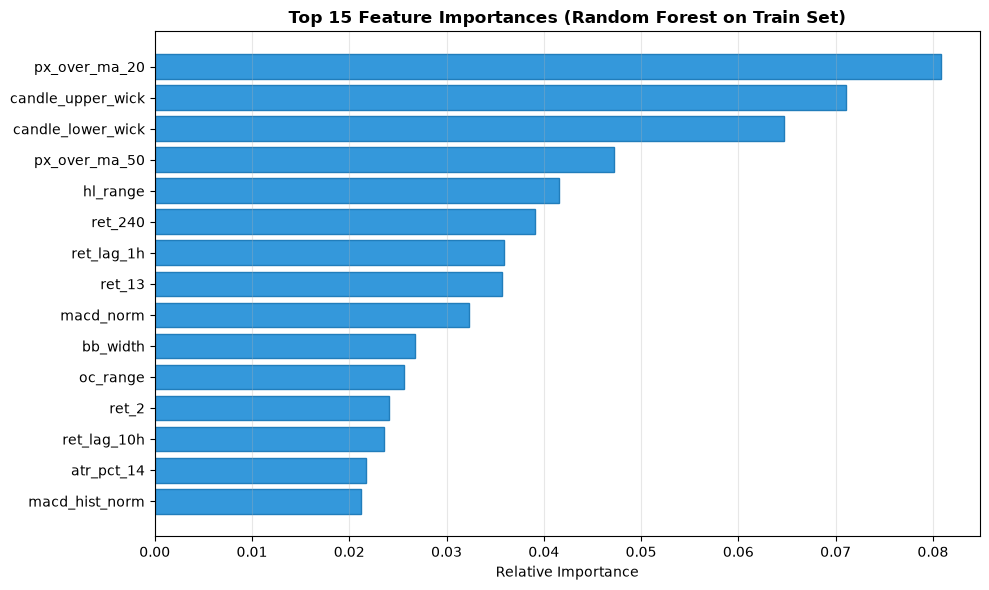

Saved feature importance plot to model_output\feature_importances_demo.png


In [7]:
# ---------- 5. Visualize Top Feature Importances ----------
top_imp = importances.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_imp.index, top_imp.values, color="#3498db", edgecolor="#217dbb")
ax.set_title("Top 15 Feature Importances (Random Forest on Train Set)", fontsize=12, fontweight='bold')
ax.set_xlabel("Relative Importance")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
feat_plot_path = os.path.join(OUT_DIR, "feature_importances_demo.png")
plt.savefig(feat_plot_path, dpi=200)
plt.show()
print(f"Saved feature importance plot to {feat_plot_path}")
